# 10 — Eta–Phi Hotspot and Pixel-Veto Check

This notebook tests whether the localized $\phi$ bump is compatible with the pixel-detector hotspot pattern discussed in EXO-18-003. It uses the 12-channel merged background MC and overlays the reference veto regions:

- 2017: $1.0 \leq \eta \leq 1.5$ and $\phi \geq 2.7$;
- 2018: $0.3 \leq \eta \leq 1.2$ and $0.4 \leq \phi \leq 0.8$.

The available output contains eta–phi histograms only; it does **not** contain missing-inner-hit multiplicity. Therefore this notebook checks geometric compatibility and selection enrichment, not the detector-level cause itself. Yields are weighted object/LJ-entry yields, not event yields.

In [1]:
import sys
from pathlib import Path

import coffea.util
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

if "numpy._core.numeric" not in sys.modules:
    sys.modules["numpy._core.numeric"] = np.core.numeric

sidm_path = str(Path.cwd()).split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)
from sidm.tools import utilities

utilities.set_plot_style()
pd.set_option("display.max_rows", 200)
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
cwd = Path.cwd()
study_dir = cwd if cwd.name == "Mother_Tracking" else cwd / "studies" / "Mother_Tracking"
INPUT_DIR = study_dir / "EtaPhi_HotSpot_12ch_bkg_full_merged_samples_v1"

SAMPLES = [
    "TTJets",
    "QCD_Pt15To20", "QCD_Pt20To30", "QCD_Pt30To50", "QCD_Pt50To80",
    "QCD_Pt80To120", "QCD_Pt120To170", "QCD_Pt170To300",
    "QCD_Pt300To470", "QCD_Pt470To600", "QCD_Pt600To800",
    "QCD_Pt800To1000", "QCD_Pt1000",
    "DYJetsToLL_M10to50", "DYJetsToLL_M50", "WW", "WZ", "ZZ",
]
BACKGROUND_GROUPS = {
    "Diboson": ["WW", "WZ", "ZZ"],
    "TT": ["TTJets"],
    "DY": [s for s in SAMPLES if s.startswith("DYJets")],
    "QCD": [s for s in SAMPLES if s.startswith("QCD_")],
}
BASE_CHANNELS = {
    "1 mu-LJ": "data_control_region_1muLj",
    "1 egm-LJ": "data_control_region_1egmLj",
    "1 mu-LJ + 1 egm-LJ": "data_control_region_1muLj_1egmLj",
    "2 mu-LJ": "data_control_region_2muLj",
}
REGIONS = {"Inclusive": "", "Signal-like": "_both_pass", "Background-like": "_both_fail"}
HISTOGRAMS = {
    "Electron": "electron_eta_phi", "Muon": "muon_eta_phi",
    "Photon": "photon_eta_phi", "DSA muon": "dsaMuon_eta_phi",
    "mu-LJ": "mu_lj_eta_phi", "egm-LJ": "egm_lj_eta_phi",
}
VETO_REGIONS = {
    "2017": {"eta": (1.0, 1.5), "phi": (2.7, np.pi), "color": "red"},
    "2018": {"eta": (0.3, 1.2), "phi": (0.4, 0.8), "color": "magenta"},
}
assert INPUT_DIR.is_dir(), f"Missing input directory: {INPUT_DIR}"
missing = [s for s in SAMPLES if not (INPUT_DIR / f"{s}.coffea").is_file()]
assert not missing, f"Missing coffea files: {missing}"
print(f"Input: {INPUT_DIR} ({len(SAMPLES)} samples)")

Input: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking/EtaPhi_HotSpot_12ch_bkg_full_merged_samples_v1 (18 samples)


## Load and validate the merged outputs

In [3]:
out = {}
validation_rows = []
expected_channels = {base + suffix for base in BASE_CHANNELS.values() for suffix in REGIONS.values()}
for sample in SAMPLES:
    loaded = coffea.util.load(INPUT_DIR / f"{sample}.coffea")
    sample_out = loaded.get("out", loaded)[sample]
    out[sample] = sample_out
    available_hists = set(sample_out["hists"])
    available_channels = set(sample_out["hists"]["electron_eta_phi"].axes["channel"])
    missing_hists = sorted(set(HISTOGRAMS.values()) - available_hists)
    missing_channels = sorted(expected_channels - available_channels)
    validation_rows.append({
        "sample": sample, "n_histograms": len(available_hists),
        "n_channels": len(available_channels),
        "missing_histograms": ", ".join(missing_hists),
        "missing_channels": ", ".join(missing_channels),
        "status": "ok" if not missing_hists and not missing_channels else "incomplete",
    })
validation = pd.DataFrame(validation_rows).set_index("sample")
display(validation)
assert validation["status"].eq("ok").all()

,n_histograms,n_channels,missing_histograms,missing_channels,status
sample,,,,,
TTJets,6,12,,,ok
QCD_Pt15To20,6,12,,,ok
QCD_Pt20To30,6,12,,,ok
QCD_Pt30To50,6,12,,,ok
QCD_Pt50To80,6,12,,,ok
QCD_Pt80To120,6,12,,,ok
QCD_Pt120To170,6,12,,,ok
QCD_Pt170To300,6,12,,,ok
QCD_Pt300To470,6,12,,,ok


## Helpers and reference-region overlays

In [4]:
def channel_name(channel_label, region):
    return BASE_CHANNELS[channel_label] + REGIONS[region]

def sum_histogram(samples, channel, histogram_name):
    total = None
    for sample in samples:
        h = out[sample]["hists"][histogram_name][{"channel": channel}]
        total = h.copy() if total is None else total + h
    return total

def eta_phi_arrays(histogram):
    eta_axis, phi_axis = histogram.axes
    values = np.asarray(histogram.values(), dtype=float)
    variances = histogram.variances()
    variances = np.abs(values) if variances is None else np.asarray(variances, dtype=float)
    return np.asarray(eta_axis.edges), np.asarray(phi_axis.edges), values, variances

def draw_map(ax, histogram, title, mode="yield"):
    eta_edges, phi_edges, values, variances = eta_phi_arrays(histogram)
    if mode == "density":
        total = values.sum()
        shown = values / total if total > 0 else np.zeros_like(values)
        mesh = ax.pcolormesh(phi_edges, eta_edges, shown, cmap="viridis", shading="auto")
        label = "Fraction / bin"
    else:
        positive = values[values > 0]
        norm = LogNorm(vmin=max(positive.min(), positive.max()*1e-4), vmax=positive.max()) if positive.size else None
        mesh = ax.pcolormesh(phi_edges, eta_edges, np.clip(values, 0, None), cmap="viridis", norm=norm, shading="auto")
        label = "Weighted entries"
    ax.set(title=title, xlabel=r"$\phi$", ylabel=r"$\eta$", xlim=(-np.pi, np.pi))
    return mesh, label

def region_stats(histogram, spec):
    eta_edges, phi_edges, values, variances = eta_phi_arrays(histogram)
    eta = 0.5 * (eta_edges[:-1] + eta_edges[1:])
    phi = 0.5 * (phi_edges[:-1] + phi_edges[1:])
    mask = ((eta[:, None] >= spec["eta"][0]) & (eta[:, None] <= spec["eta"][1]) &
            (phi[None, :] >= spec["phi"][0]) & (phi[None, :] <= spec["phi"][1]))
    selected = float(values[mask].sum())
    variance = float(variances[mask].sum())
    total = float(values.sum())
    return selected, np.sqrt(max(variance, 0)), total, selected / total if total > 0 else np.nan


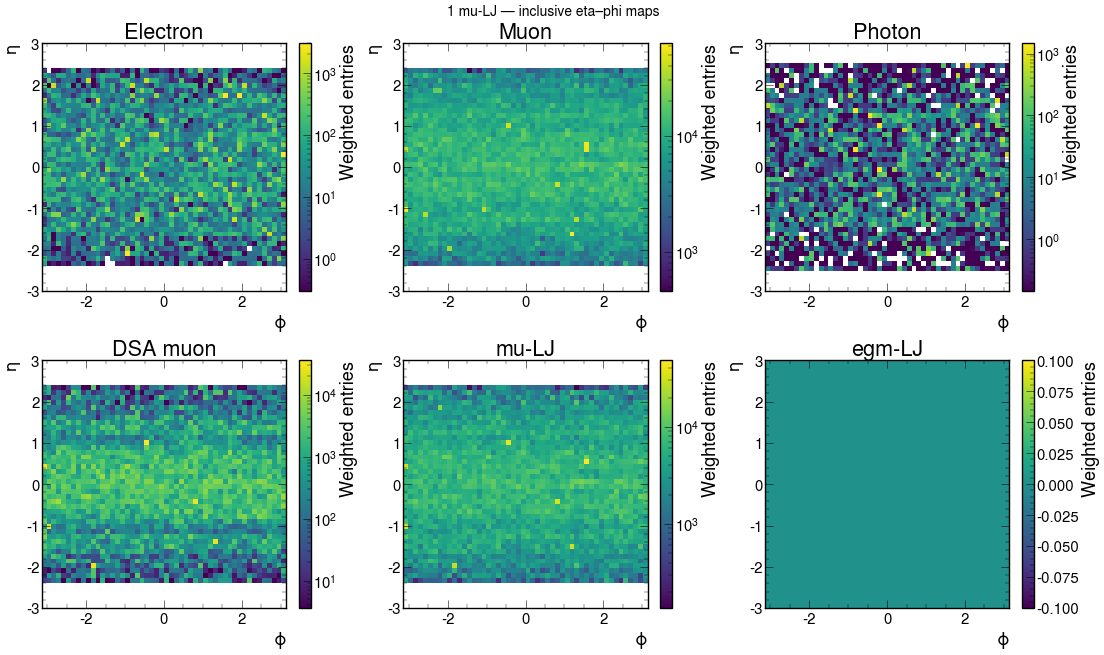

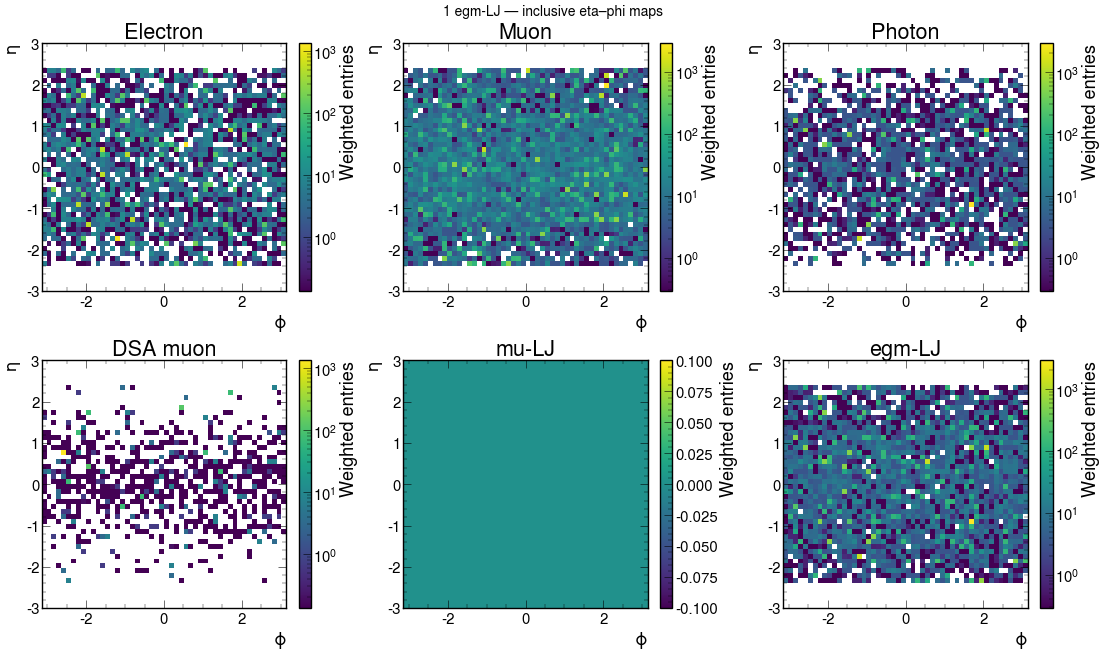

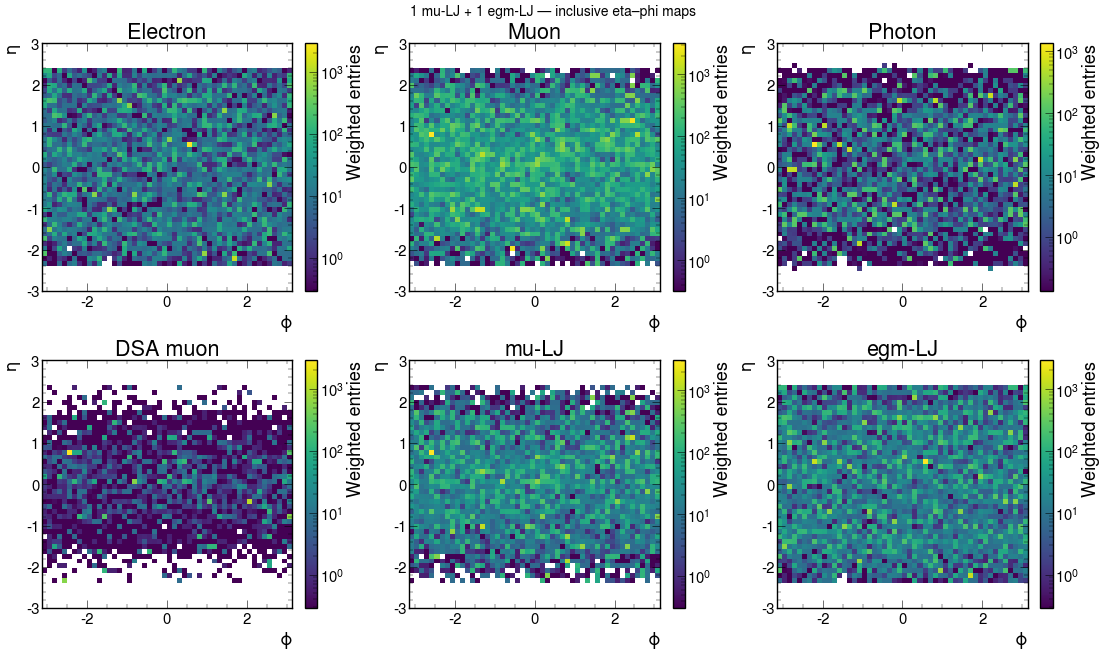

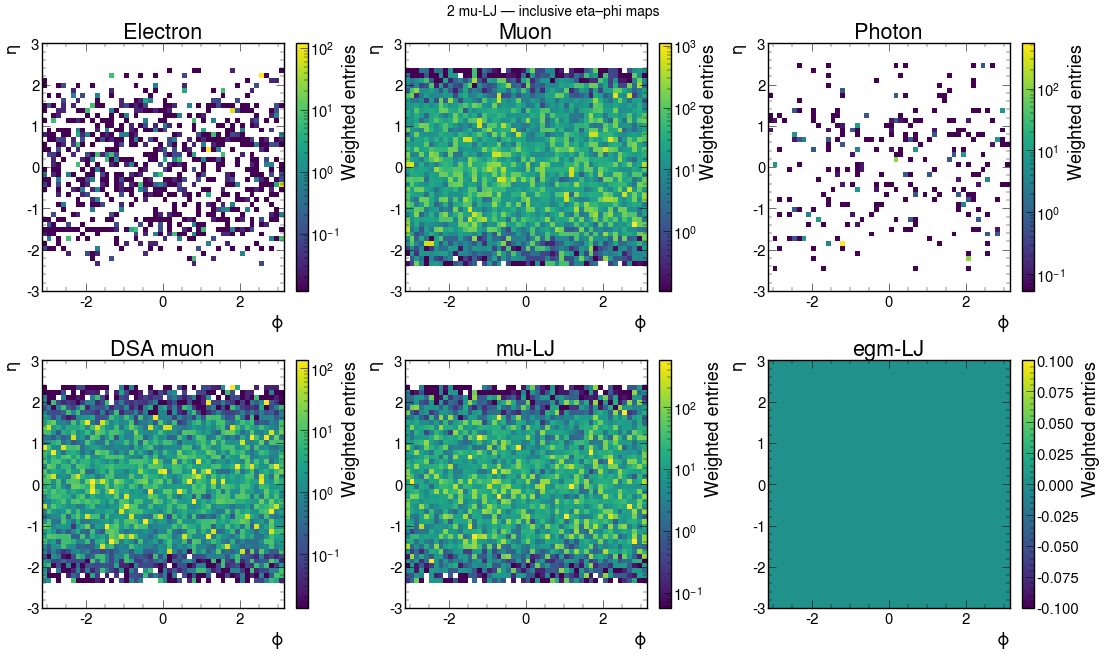

In [5]:
for channel_label in BASE_CHANNELS:
    fig, axes = plt.subplots(2, 3, figsize=(22, 13), constrained_layout=True)
    for ax, (object_label, histogram_name) in zip(axes.flat, HISTOGRAMS.items()):
        h = sum_histogram(SAMPLES, channel_name(channel_label, "Inclusive"), histogram_name)
        mesh, cbar_label = draw_map(ax, h, object_label, mode="yield")
        fig.colorbar(mesh, ax=ax, label=cbar_label)
    fig.suptitle(f"{channel_label} — inclusive eta–phi maps", fontsize=20)
    plt.show(); plt.close(fig)

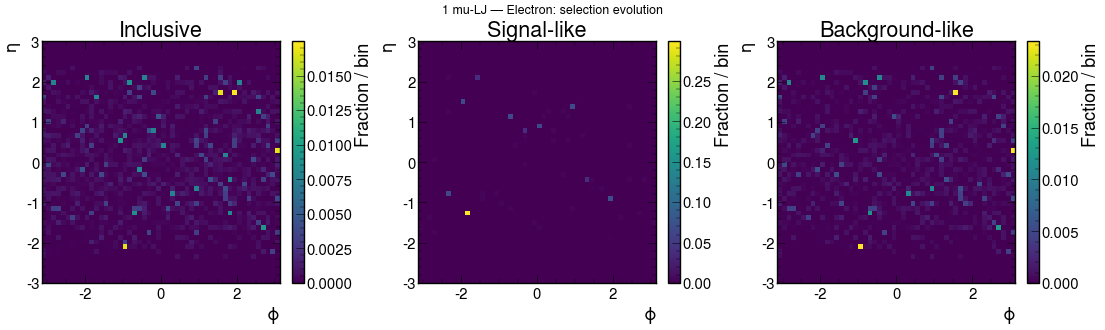

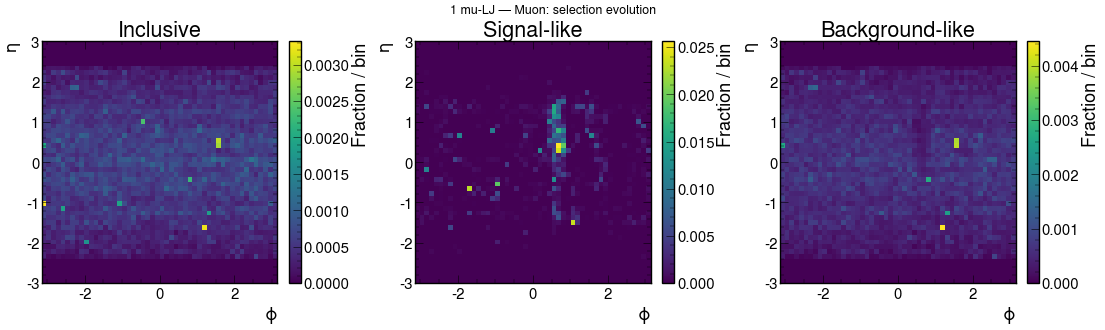

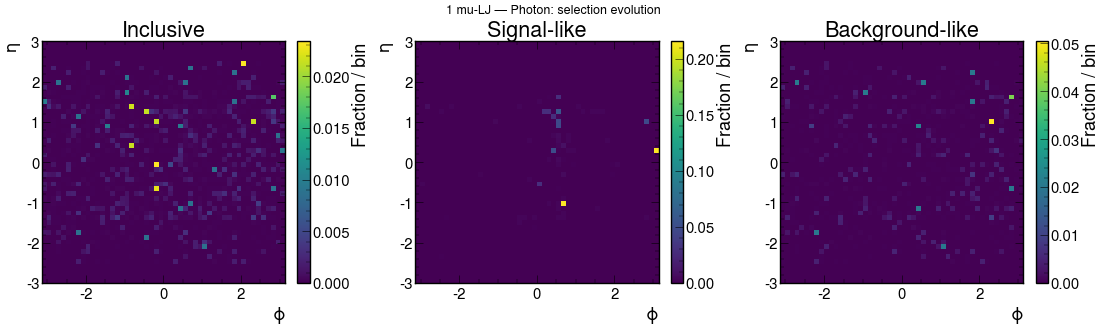

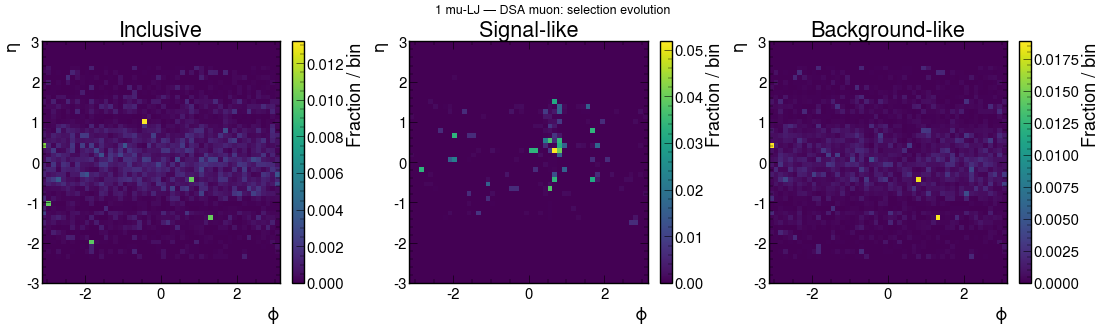

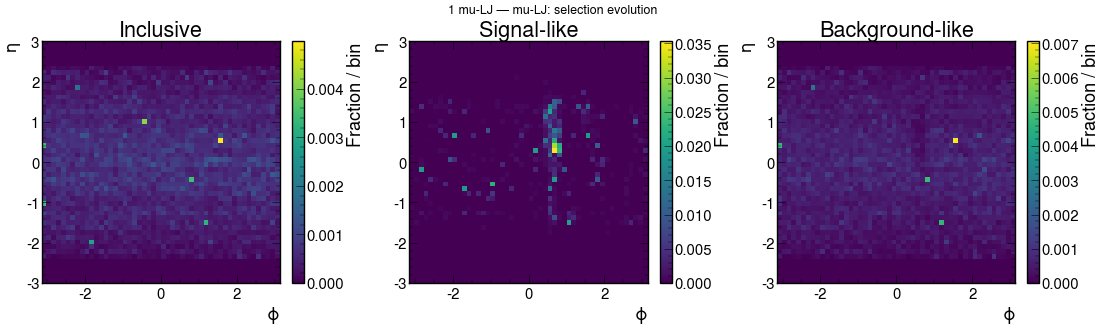

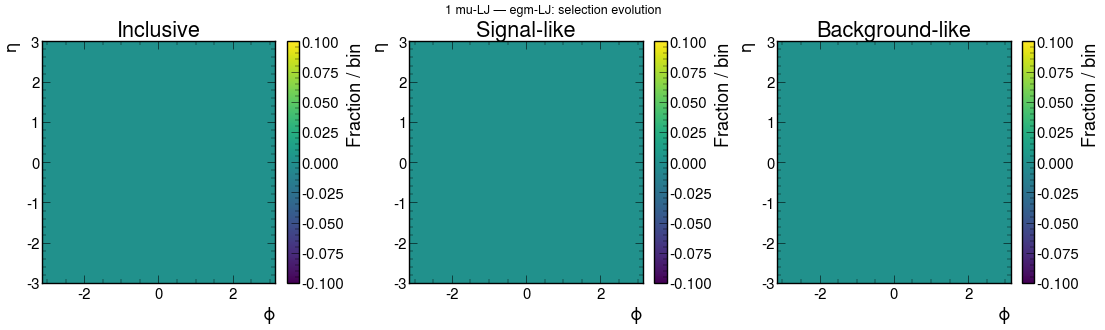

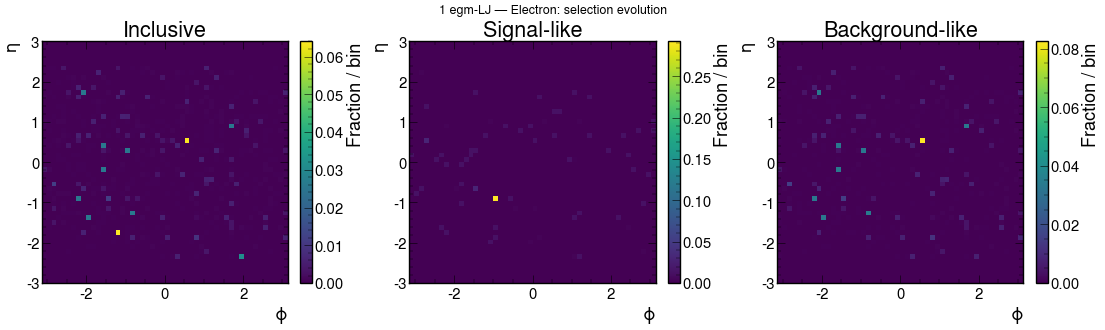

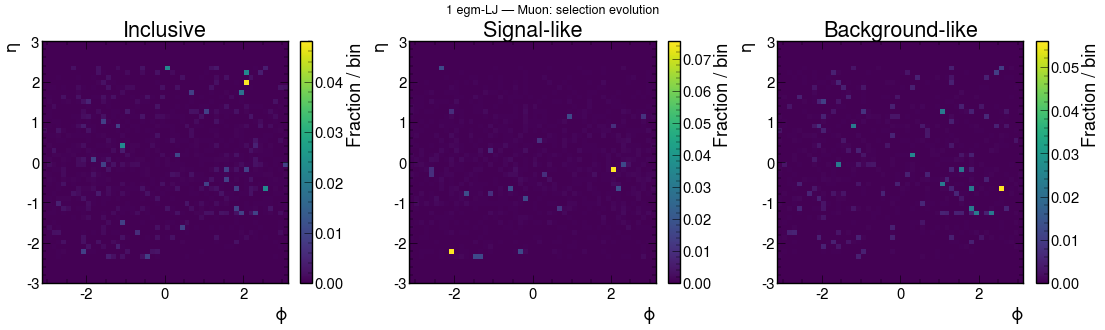

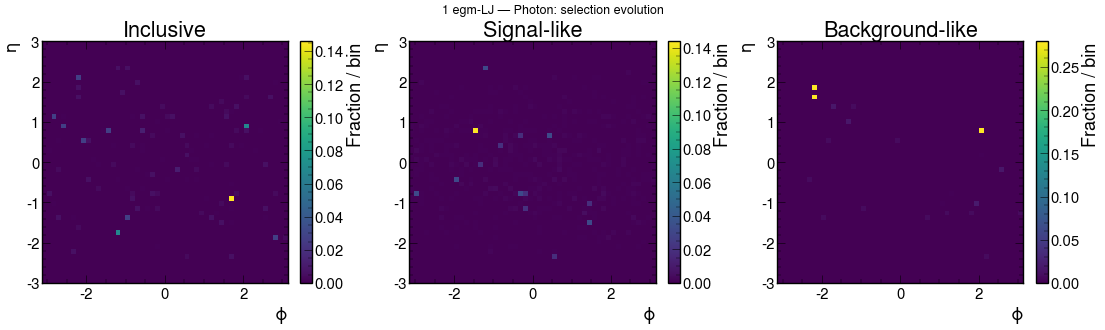

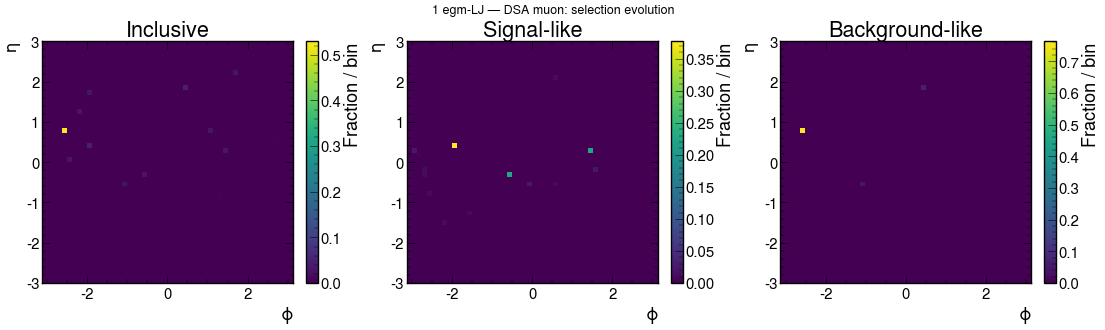

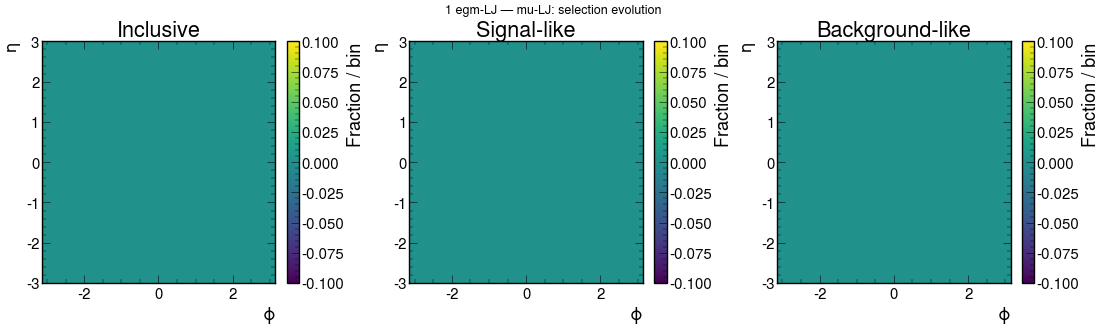

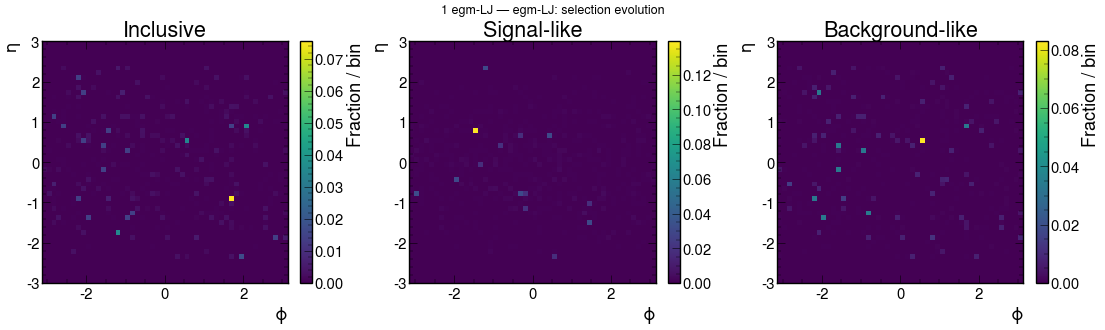

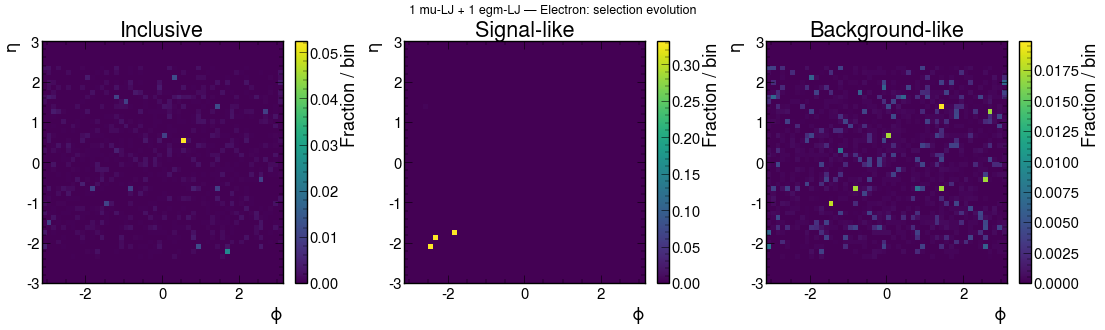

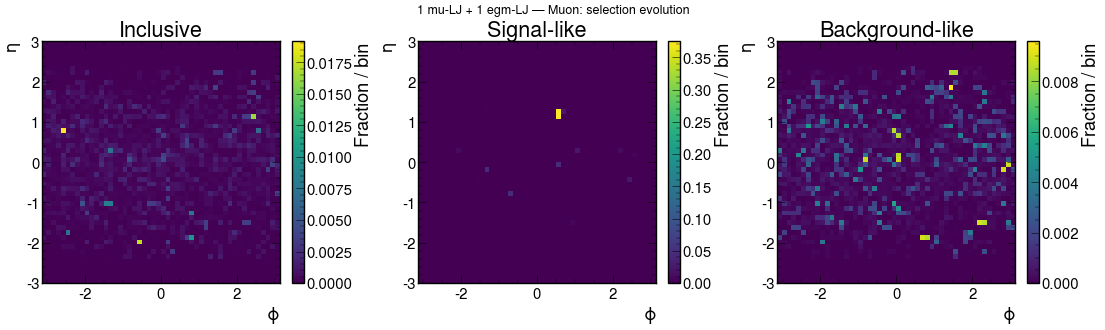

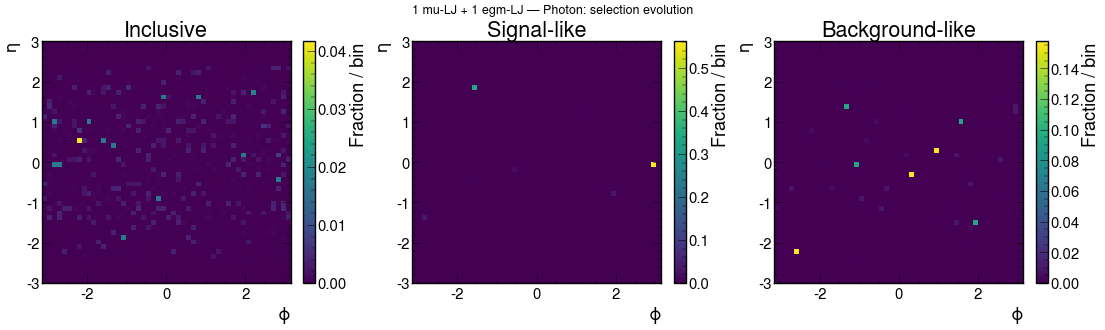

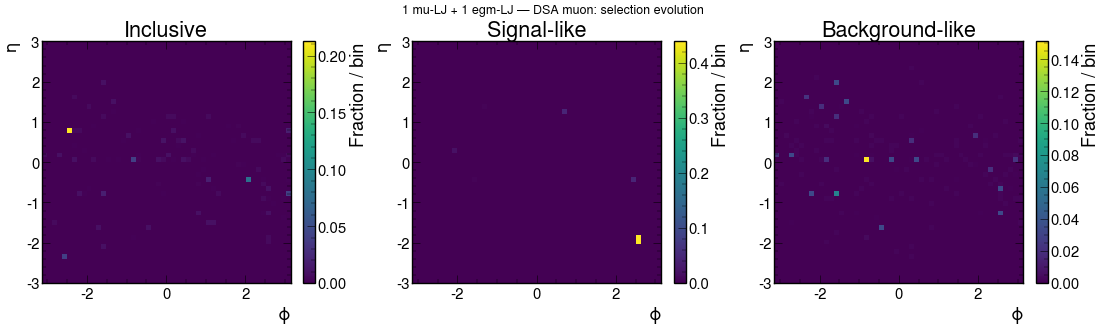

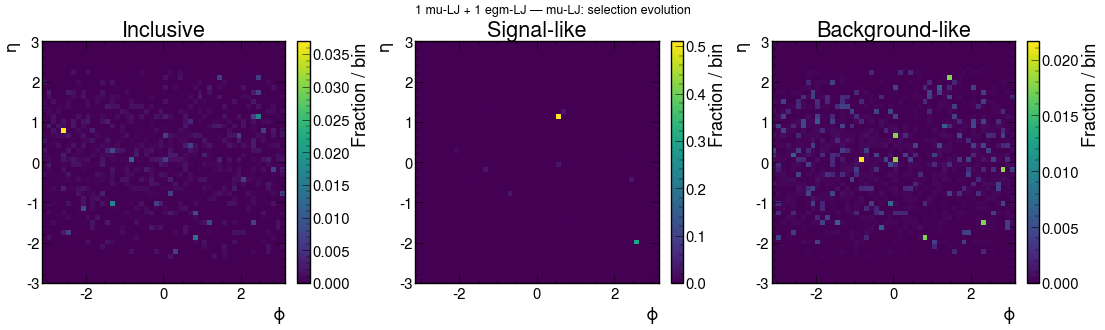

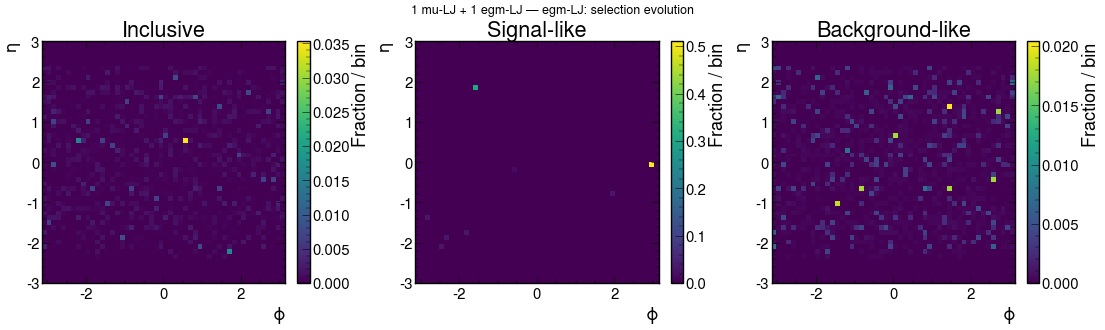

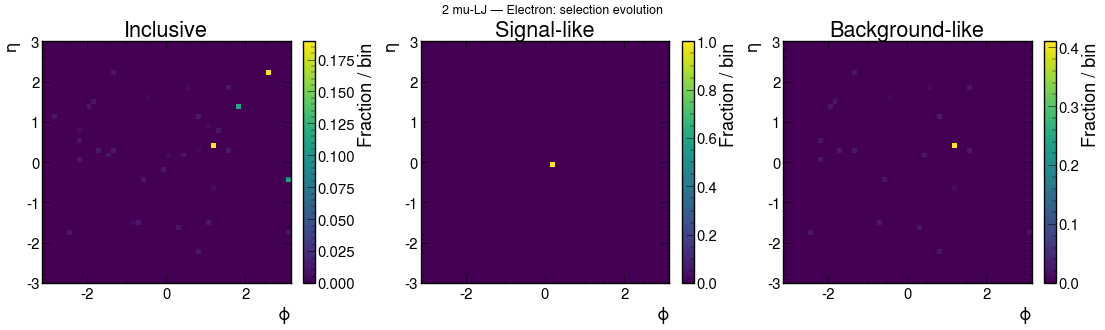

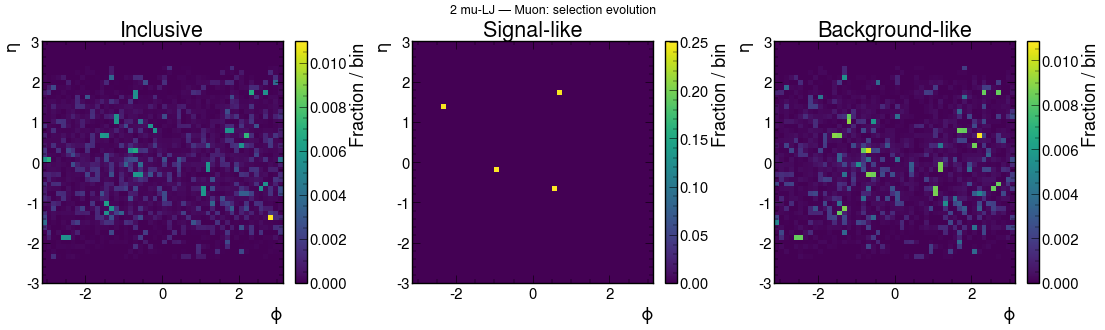

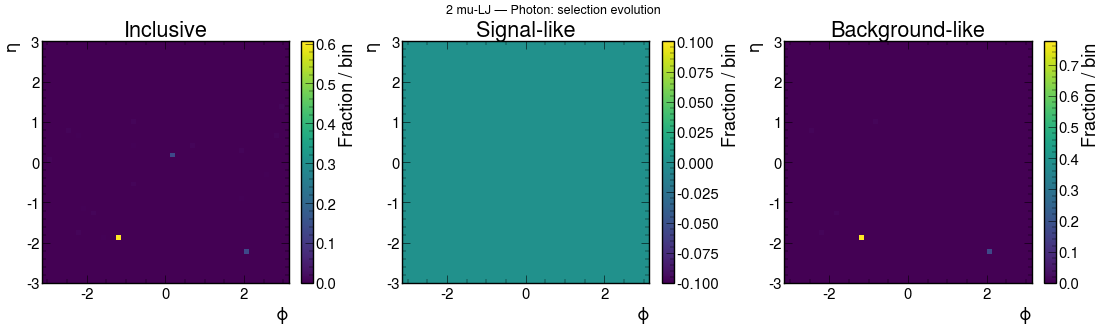

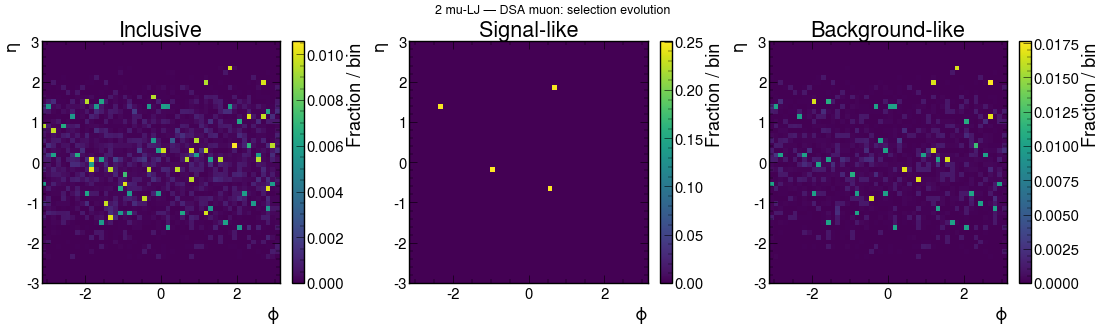

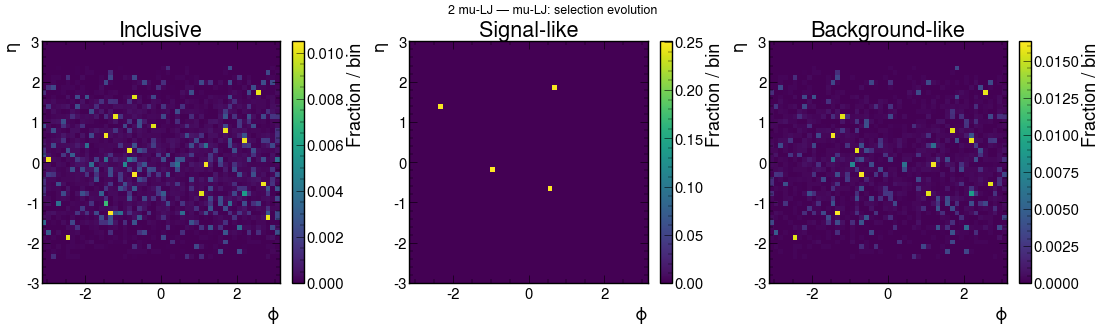

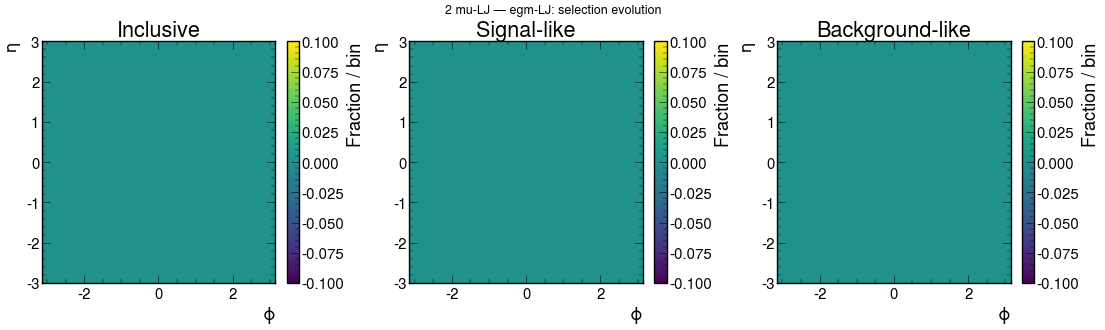

In [6]:
for channel_label in BASE_CHANNELS:
    for object_label, histogram_name in HISTOGRAMS.items():
        fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), constrained_layout=True)
        for ax, region in zip(axes, REGIONS):
            h = sum_histogram(SAMPLES, channel_name(channel_label, region), histogram_name)
            mesh, cbar_label = draw_map(ax, h, region, mode="density")
            fig.colorbar(mesh, ax=ax, label=cbar_label)
        fig.suptitle(f"{channel_label} — {object_label}: selection evolution", fontsize=18)
        plt.show(); plt.close(fig)

In [7]:
occupancy_rows = []
for channel_label in BASE_CHANNELS:
    for object_label, histogram_name in HISTOGRAMS.items():
        fractions = {}
        for region in REGIONS:
            h = sum_histogram(SAMPLES, channel_name(channel_label, region), histogram_name)
            for year, spec in VETO_REGIONS.items():
                selected, error, total, fraction = region_stats(h, spec)
                fractions[(region, year)] = fraction
                occupancy_rows.append({
                    "channel": channel_label, "object": object_label, "selection": region,
                    "reference": year, "region yield": selected, "region uncertainty": error,
                    "total yield": total, "region fraction": fraction,
                })
occupancy = pd.DataFrame(occupancy_rows)
fraction_table = occupancy.pivot_table(index=["channel", "object"], columns=["reference", "selection"], values="region fraction")
for year in VETO_REGIONS:
    fraction_table[(year, "pass / inclusive")] = (
        fraction_table[(year, "Signal-like")] / fraction_table[(year, "Inclusive")]
    )
display((100 * fraction_table).round(3).style.format("{:.3f}"))

## Phi projections inside the suspect eta bands

These projections directly test the reported phi bump while controlling eta. Curves are unit-normalized within the indicated eta band.

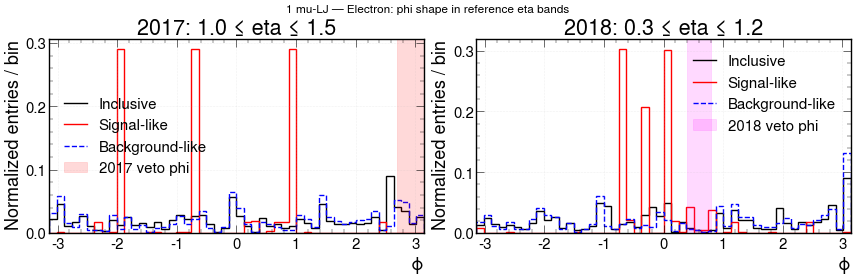

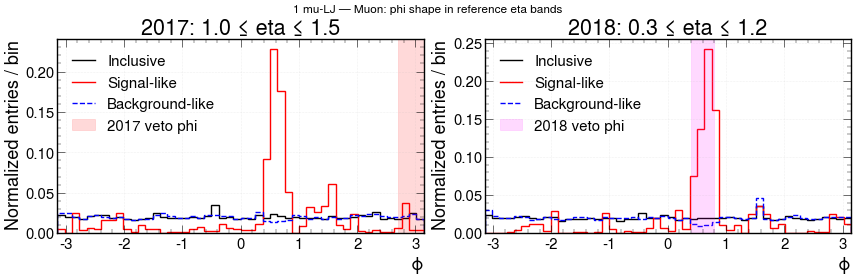

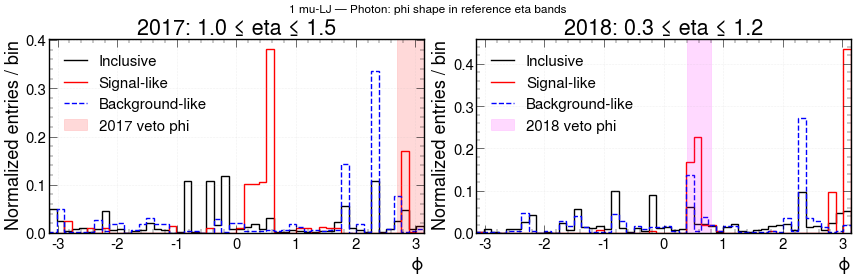

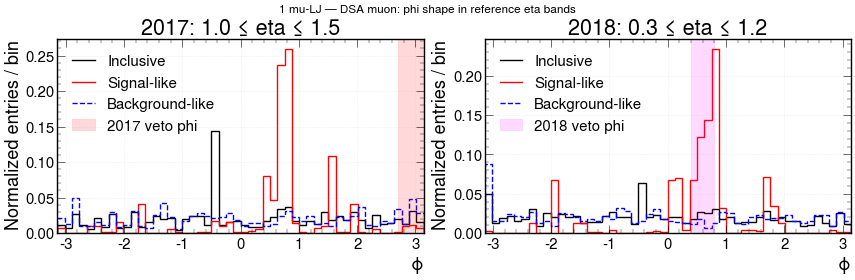

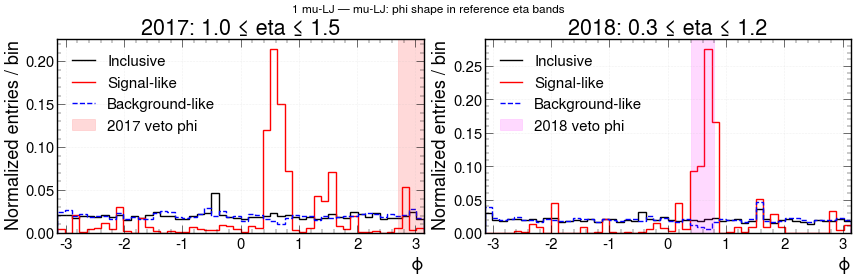

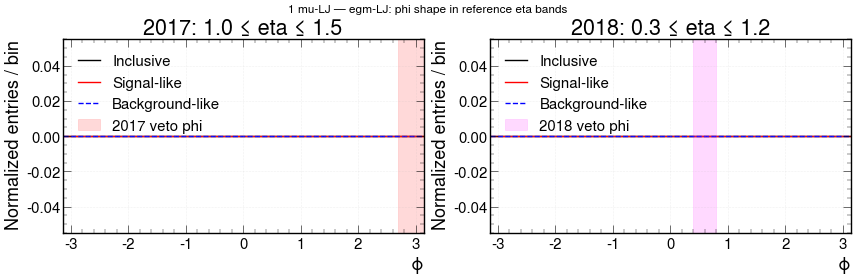

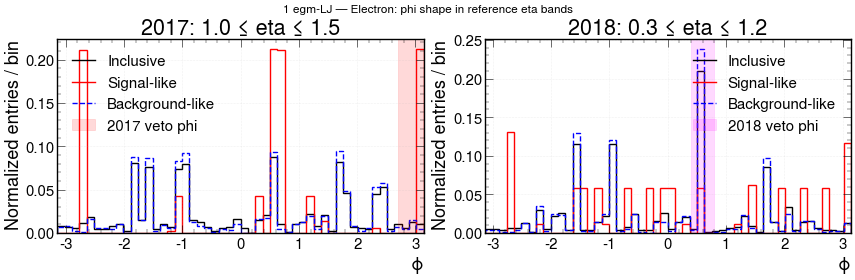

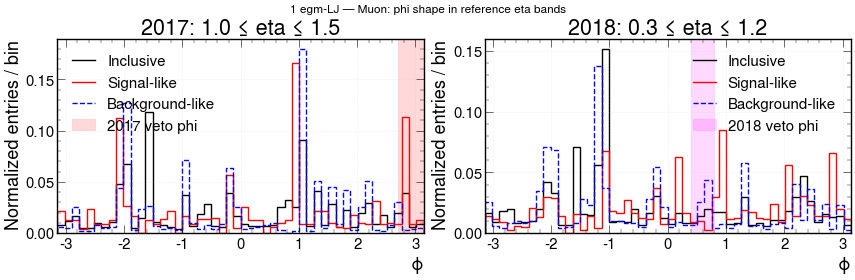

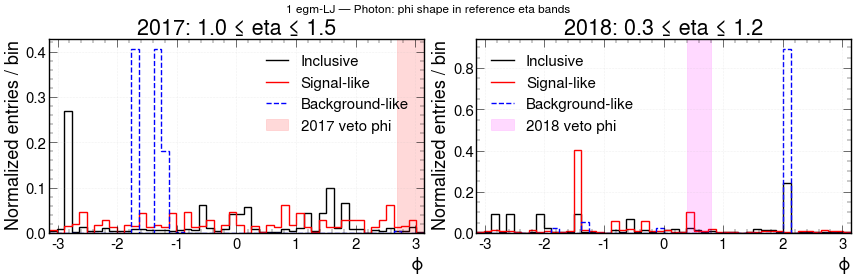

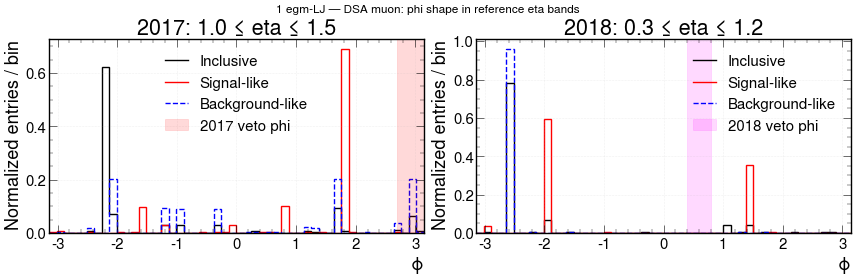

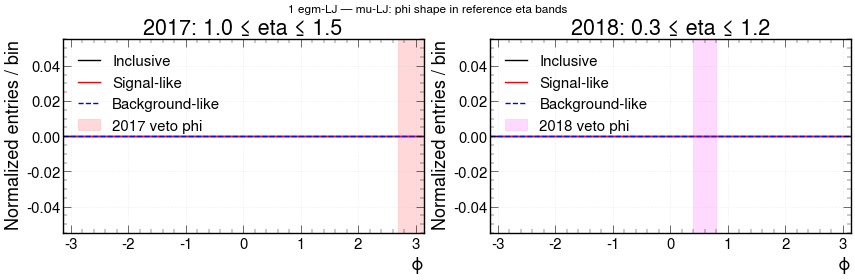

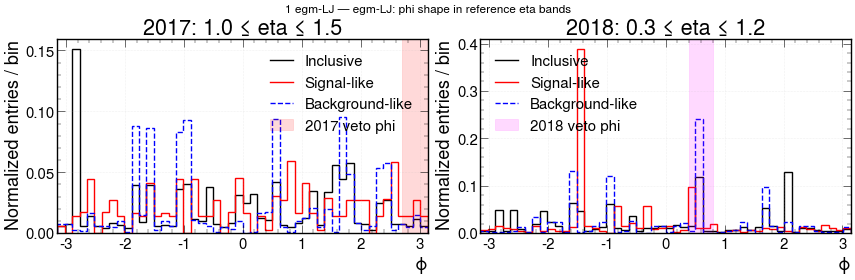

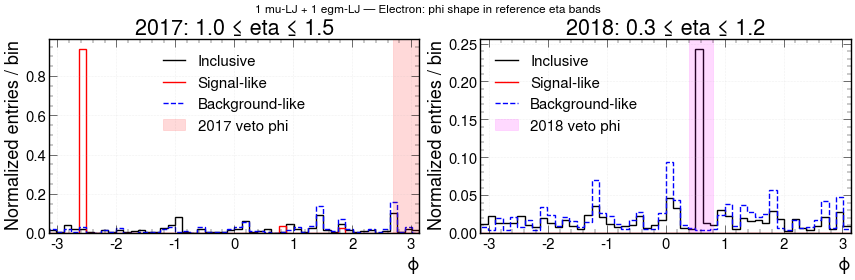

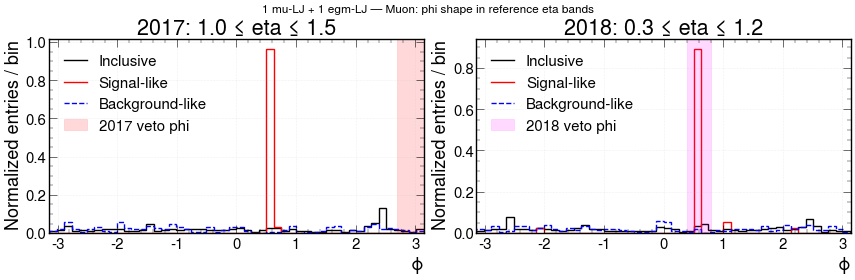

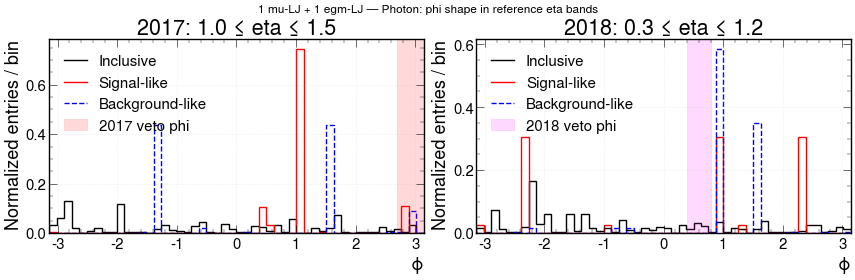

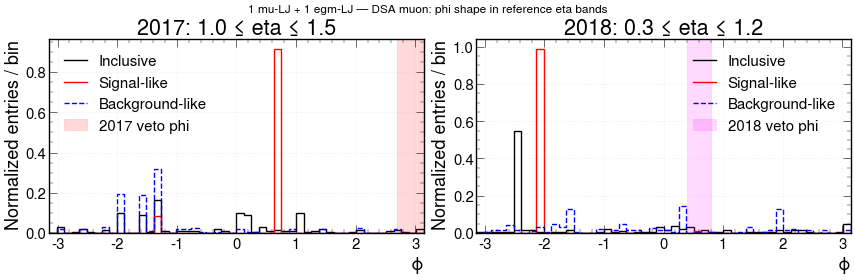

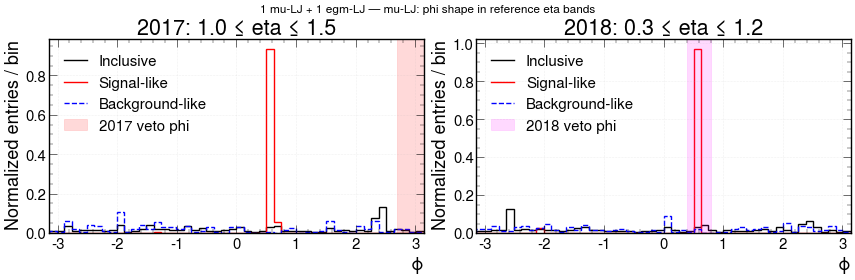

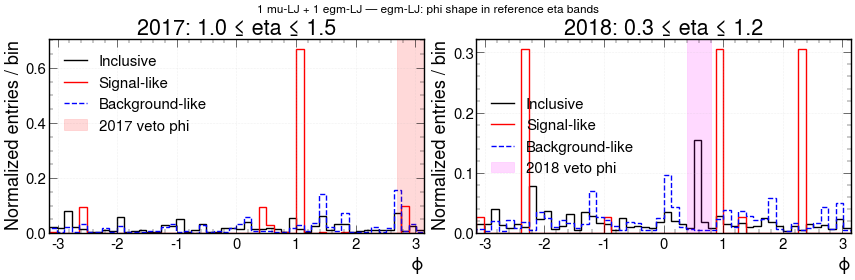

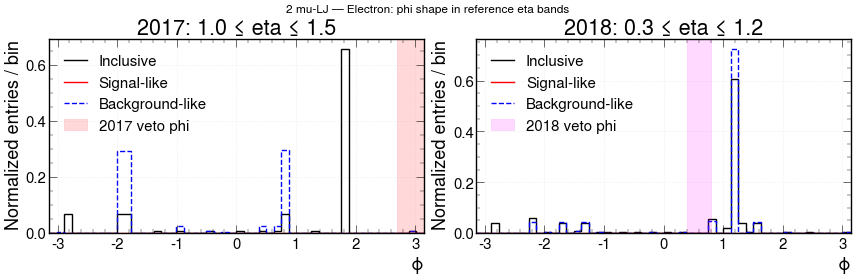

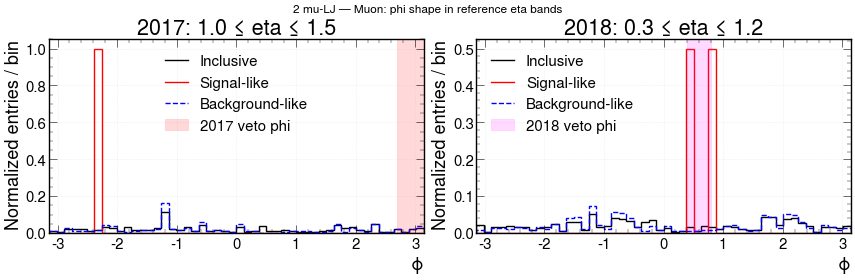

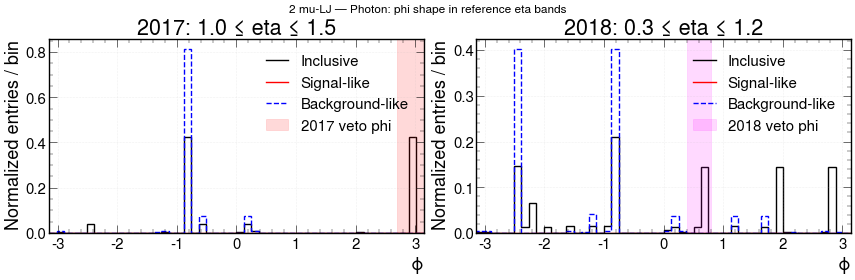

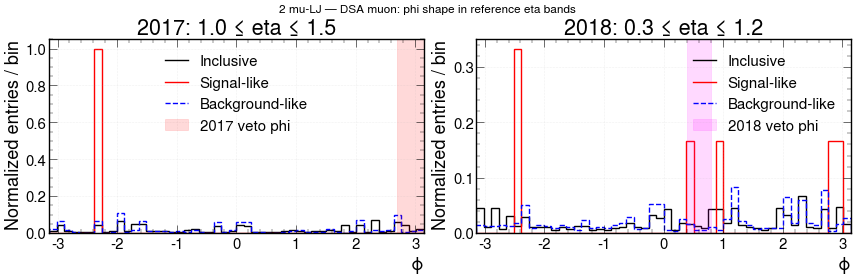

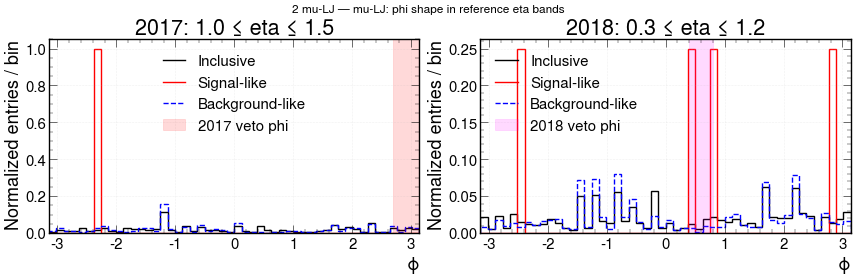

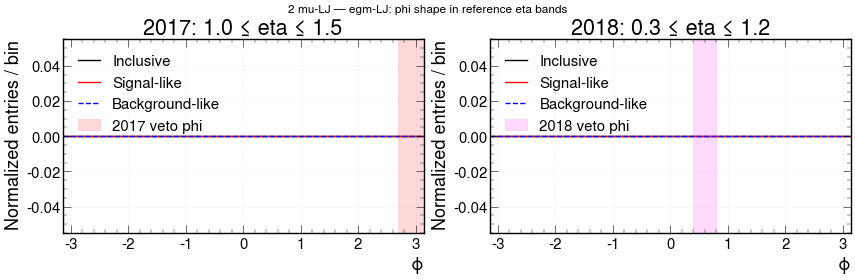

In [8]:
REGION_STYLES = {"Inclusive": ("black", "-"), "Signal-like": ("red", "-"), "Background-like": ("blue", "--")}
def phi_projection(histogram, eta_range):
    eta_edges, phi_edges, values, _ = eta_phi_arrays(histogram)
    eta = 0.5 * (eta_edges[:-1] + eta_edges[1:])
    selected = (eta >= eta_range[0]) & (eta <= eta_range[1])
    projection = values[selected, :].sum(axis=0)
    total = projection.sum()
    return phi_edges, projection / total if total > 0 else np.zeros_like(projection)

for channel_label in BASE_CHANNELS:
    for object_label, histogram_name in HISTOGRAMS.items():
        fig, axes = plt.subplots(1, 2, figsize=(17, 5.5), constrained_layout=True)
        for ax, (year, spec) in zip(axes, VETO_REGIONS.items()):
            for region, (color, linestyle) in REGION_STYLES.items():
                h = sum_histogram(SAMPLES, channel_name(channel_label, region), histogram_name)
                edges, shape = phi_projection(h, spec["eta"])
                ax.stairs(shape, edges, color=color, linestyle=linestyle, linewidth=2, label=region)
            ax.axvspan(*spec["phi"], color=spec["color"], alpha=0.15, label=f"{year} veto phi")
            ax.set(title=f"{year}: {spec['eta'][0]} ≤ eta ≤ {spec['eta'][1]}", xlabel=r"$\phi$", ylabel="Normalized entries / bin", xlim=(-np.pi, np.pi))
            ax.grid(linestyle=":", alpha=0.35); ax.legend(frameon=False)
        fig.suptitle(f"{channel_label} — {object_label}: phi shape in reference eta bands", fontsize=17)
        plt.show(); plt.close(fig)

In [9]:
process_rows = []
for channel_label in BASE_CHANNELS:
    channel = channel_name(channel_label, "Signal-like")
    for object_label, histogram_name in HISTOGRAMS.items():
        for process, samples in BACKGROUND_GROUPS.items():
            h = sum_histogram(samples, channel, histogram_name)
            for year, spec in VETO_REGIONS.items():
                selected, error, total, fraction = region_stats(h, spec)
                process_rows.append({"channel": channel_label, "object": object_label,
                                     "process": process, "reference": year,
                                     "region fraction": fraction, "region yield": selected})
process_occupancy = pd.DataFrame(process_rows)
display((100 * process_occupancy.pivot_table(index=["channel", "object"], columns=["reference", "process"], values="region fraction")).round(3))

reference                     2017                          2018          \
process                         DY Diboson    QCD     TT      DY Diboson   
channel            object                                                  
1 egm-LJ           DSA muon  0.000     NaN  0.001  0.000   0.000     NaN   
                   Electron  0.000     0.0  0.000  4.545   0.000   0.000   
                   Muon      1.097     0.0  2.018  0.962   0.798   2.303   
                   Photon    0.826     0.0  0.005  0.000   2.065   4.537   
                   egm-LJ    0.806     0.0  0.005  2.000   2.015   4.537   
1 mu-LJ            DSA muon  1.481     0.0  0.449  0.000  15.081  31.665   
                   Electron  0.000     0.0  0.002  0.000  74.558   0.000   
                   Muon      1.435     0.0  1.099  0.000  11.888  20.640   
                   Photon    0.000     0.0  4.991  0.000  11.198   0.000   
                   mu-LJ     2.011     0.0  1.483  0.000  18.654  27.424   
1 mu-LJ + 1 egm-LJ DSA muon    NaN     NaN  0.000  0.000     NaN     NaN   
                   Electron    NaN     NaN  0.000    NaN     NaN     NaN   
                   Muon        NaN     NaN  0.000  0.000     NaN     NaN   
                   Photon      NaN     NaN  0.046  0.000     NaN     NaN   
                   egm-LJ      NaN     NaN  0.042  0.000     NaN     NaN   
                   mu-LJ       NaN     NaN  0.000  0.000     NaN     NaN   
2 mu-LJ            DSA muon  0.000     NaN  0.000  0.000   0.000     NaN   
                   Electron    NaN     NaN  0.000    NaN     NaN     NaN   
                   Muon      0.000     NaN  0.000  0.000   0.000     NaN   
                   mu-LJ     0.000     NaN  0.000  0.000   0.000     NaN   

reference                                    
process                         QCD      TT  
channel            object                    
1 egm-LJ           DSA muon   0.002   0.000  
                   Electron   0.004   4.545  
                   Muon       0.038   0.962  
                   Photon     5.825   9.677  
                   egm-LJ     5.764   8.000  
1 mu-LJ            DSA muon  16.826  15.000  
                   Electron   0.536   0.000  
                   Muon      19.126  21.622  
                   Photon    20.769  33.333  
                   mu-LJ     20.596  28.571  
1 mu-LJ + 1 egm-LJ DSA muon   0.020   0.000  
                   Electron   0.000     NaN  
                   Muon      38.309   0.000  
                   Photon     0.000   0.000  
                   egm-LJ     0.000   0.000  
                   mu-LJ     51.766   0.000  
2 mu-LJ            DSA muon   7.143   0.000  
                   Electron   0.000     NaN  
                   Muon      25.000   0.000  
                   mu-LJ     12.500   0.000

## Interpretation checklist

Evidence supporting the pixel-hotspot hypothesis would be: (1) a localized excess overlapping a reference rectangle, (2) increased rectangle occupancy in Signal-like relative to inclusive/background-like selections, and (3) the feature appearing across more than one background process. Absence from prompt muons but presence in electrons/egm-LJs would also resemble the reference observation.

A veto should **not** be adopted from these plots alone. Confirm the feature in collision data split by year/run, inspect missing-inner-hit or valid-pixel-hit variables for objects inside and outside the rectangle, and quantify signal efficiency plus background rejection before changing the selection.